In [55]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn 
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [57]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [58]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.620842,72.681289,71.373218,71.627092,135480400
2020-01-03,71.914803,72.676431,71.689942,71.847102,146322800
2020-01-06,72.487846,72.526533,70.783248,71.034709,118387200
2020-01-07,72.146927,72.753808,71.926900,72.497514,108872000
2020-01-08,73.307526,73.609760,71.849548,71.849548,132079200
...,...,...,...,...,...
2025-05-23,195.270004,197.699997,193.460007,193.669998,78432900
2025-05-27,200.210007,200.740005,197.429993,198.300003,56288500


<Axes: xlabel='Date'>

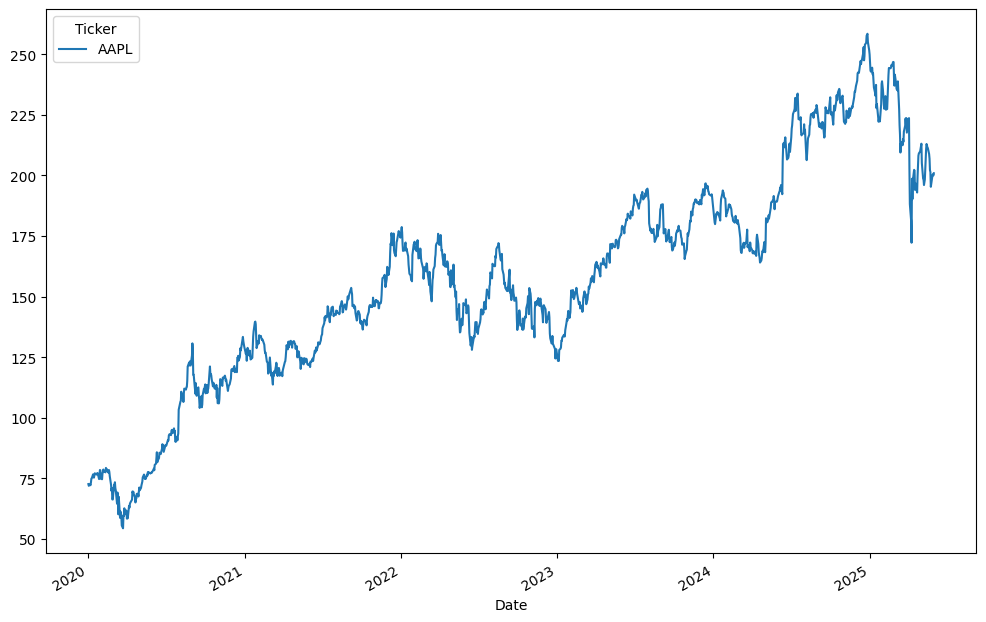

In [59]:
df.Close.plot(figsize=(12,8))

In [60]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [61]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.902033
2020-01-03,-1.917942
2020-01-06,-1.905030
2020-01-07,-1.912712
2020-01-08,-1.886560
...,...
2025-05-23,0.861585
2025-05-27,0.972897
2025-05-28,0.977629


In [62]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [63]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [64]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [65]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [66]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [67]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 <built-in method item of Tensor object at 0x000002351DFF9E50>
25 <built-in method item of Tensor object at 0x000002351E101310>
50 <built-in method item of Tensor object at 0x000002351E0CA630>
75 <built-in method item of Tensor object at 0x000002351DF78450>
100 <built-in method item of Tensor object at 0x00000235195FFD10>
125 <built-in method item of Tensor object at 0x000002351E0CA630>
150 <built-in method item of Tensor object at 0x000002351DF78D60>
175 <built-in method item of Tensor object at 0x000002351E0CA450>


In [68]:
model.eval()
y_test_pred = model(X_test)

# Convert tensors to numpy arrays first
y_train_pred_np = y_train_pred.detach().cpu().numpy()
y_train_np = y_train.detach().cpu().numpy()
y_test_pred_np = y_test_pred.detach().cpu().numpy()
y_test_np = y_test.detach().cpu().numpy()

# Then inverse transform
y_train_pred = scaler.inverse_transform(y_train_pred_np)
y_train = scaler.inverse_transform(y_train_np)
y_test_pred = scaler.inverse_transform(y_test_pred_np)
y_test = scaler.inverse_transform(y_test_np)

In [69]:
import numpy as np

def root_mean_square_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [70]:
train_rmse = root_mean_square_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_square_error(y_test[:, 0], y_test_pred[:, 0])

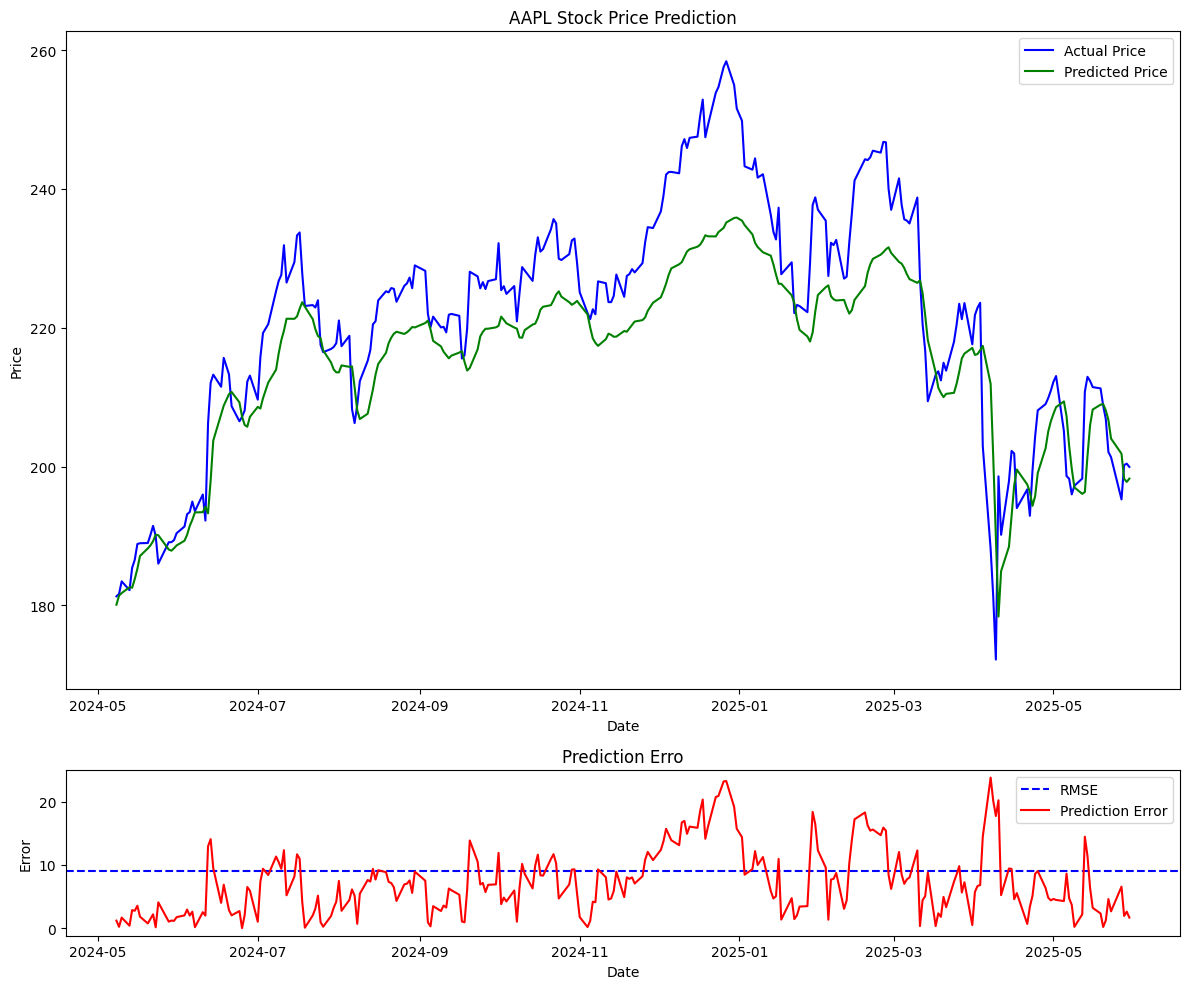

In [71]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle='--', label = 'RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Erro')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()